# Comparison MDA vs KMeans

In [ ]:
import pandas as pd
import xarray as xr
from bluemath_tk.datamining.kma import KMA
from bluemath_tk.datamining.mda import MDA
from utils.plotting import plot_variable_combinations

## Load Dataset

In [2]:
data = (
    xr.open_dataset(
        "/workspaces/BlueMath/toolkit/data/inputs/waves/ERA5_bulk_waves_2020.nc"
    )
    .isel(longitude=0, latitude=0)
    .rename({"swh": "Hs", "pp1d": "Tp", "mwd": "Dir"})
    .to_dataframe()
    .reset_index()
    .drop(columns=["latitude", "longitude", "valid_time", "meanSea", "number"])
)
data

,Hs,Tp,Dir
0,1.022461,6.519531,306.250000
1,1.015625,6.453125,306.750000
2,0.999512,6.386719,307.250000
3,0.973633,6.328125,308.000000
4,0.942383,6.273438,308.500000
...,...,...,...
8779,0.581055,4.960938,19.828125
8780,0.567383,4.933594,21.015625
8781,0.554688,4.910156,22.109375
8782,0.540527,4.886719,21.937500


In [3]:
num_centers = 100
dir_vars = ["Dir"]

mda = MDA(num_centers=num_centers)
nearest_centroids_idxs, nearest_centroids_df = mda.fit_predict(
    data=data,
    directional_variables=dir_vars,
)

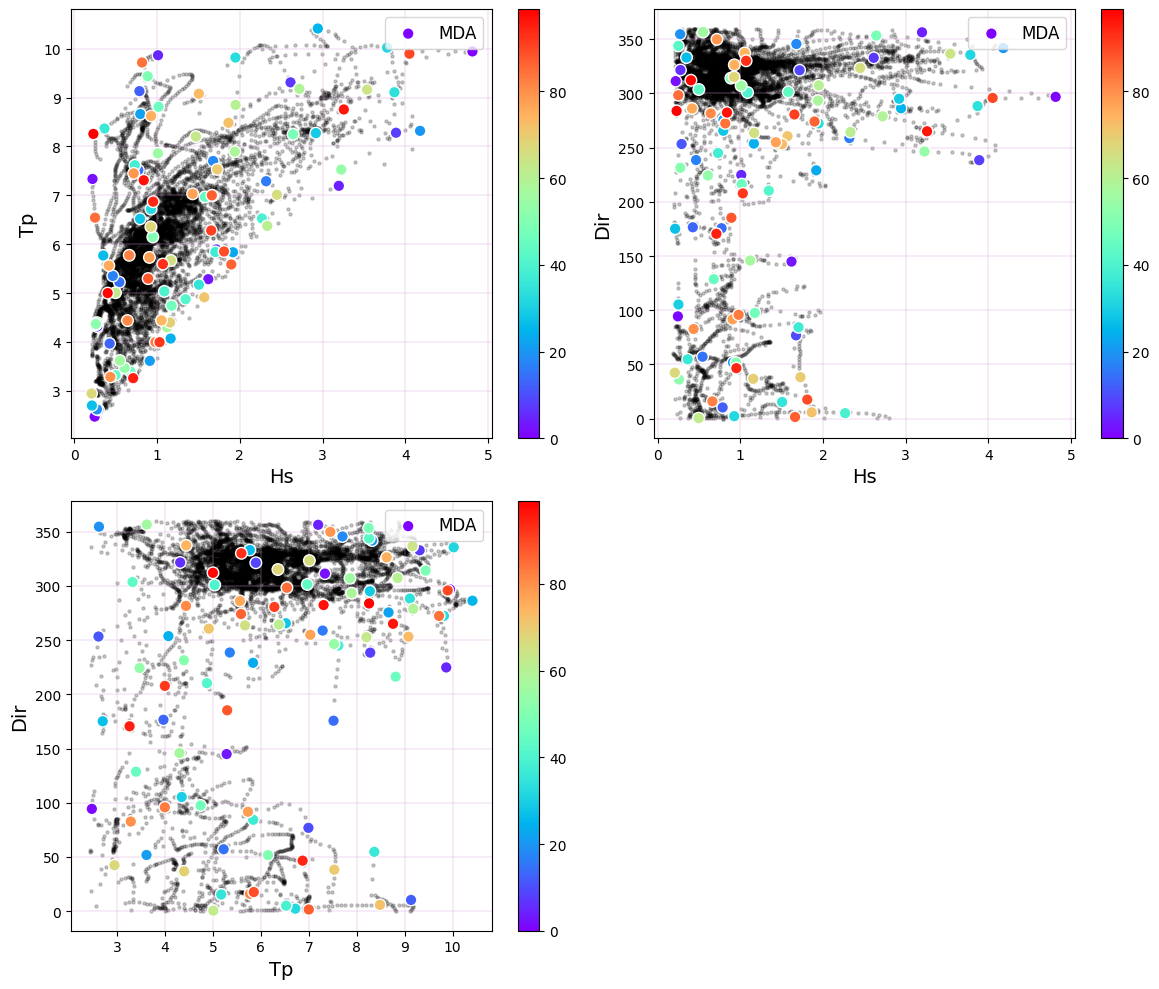

In [4]:
vars = ["Hs", "Tp", "Dir"]  # Lista de variables
sel_mda = mda.centroids[vars]  # Selección de puntos
plot_variable_combinations(mda.data, vars, mda.centroids, labels="MDA")

## KMA

In [5]:
num_centers = 100
dir_vars = ["Dir"]

kma = KMA(num_clusters=num_centers)
nearest_centroids_idxs, nearest_centroids_df = kma.fit_predict(
    data=data,
    directional_variables=dir_vars,
)

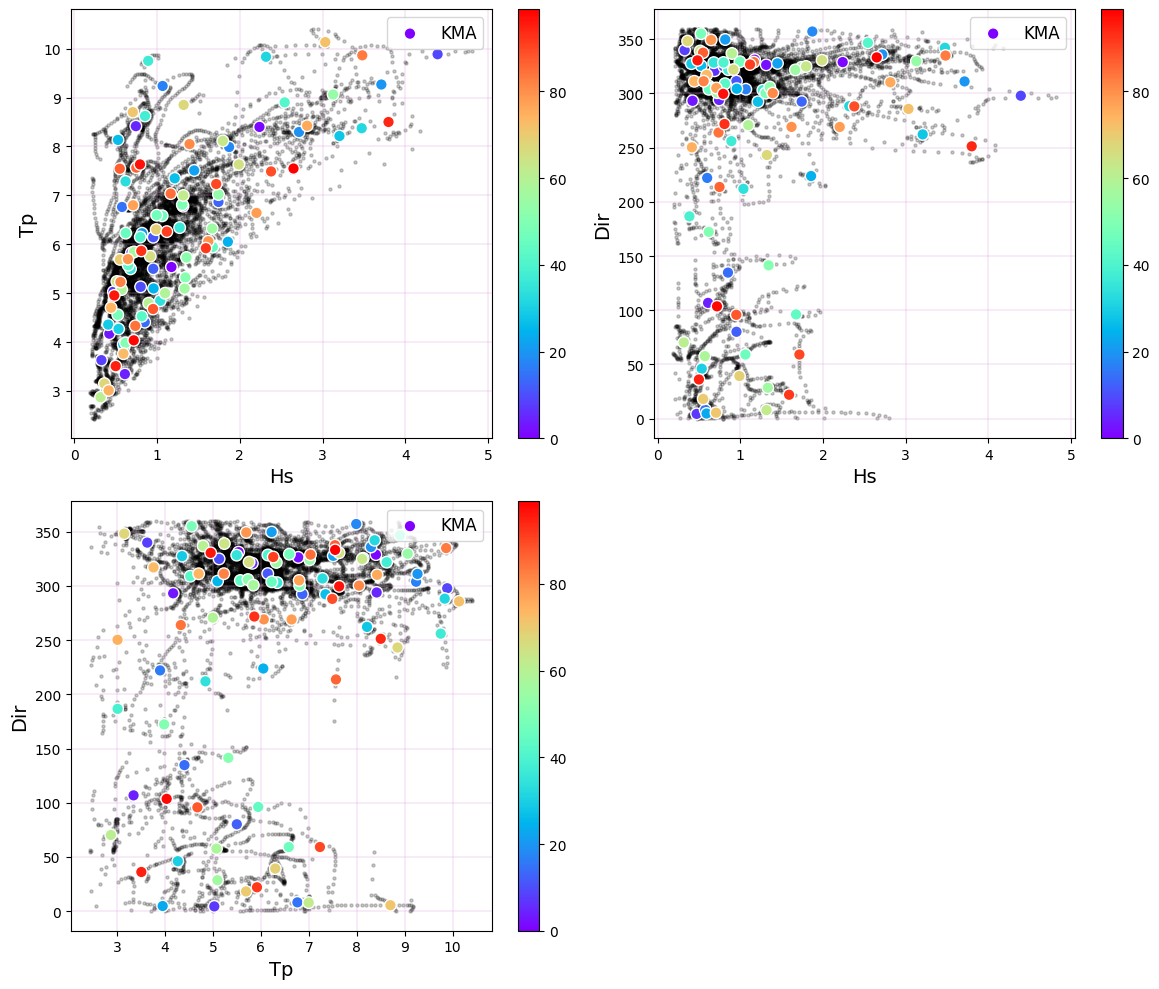

In [6]:
vars = ["Hs", "Tp", "Dir"]  # Lista de variables
plot_variable_combinations(kma.data, vars, kma.centroids, labels="KMA")

## Compare MDA vs KMA

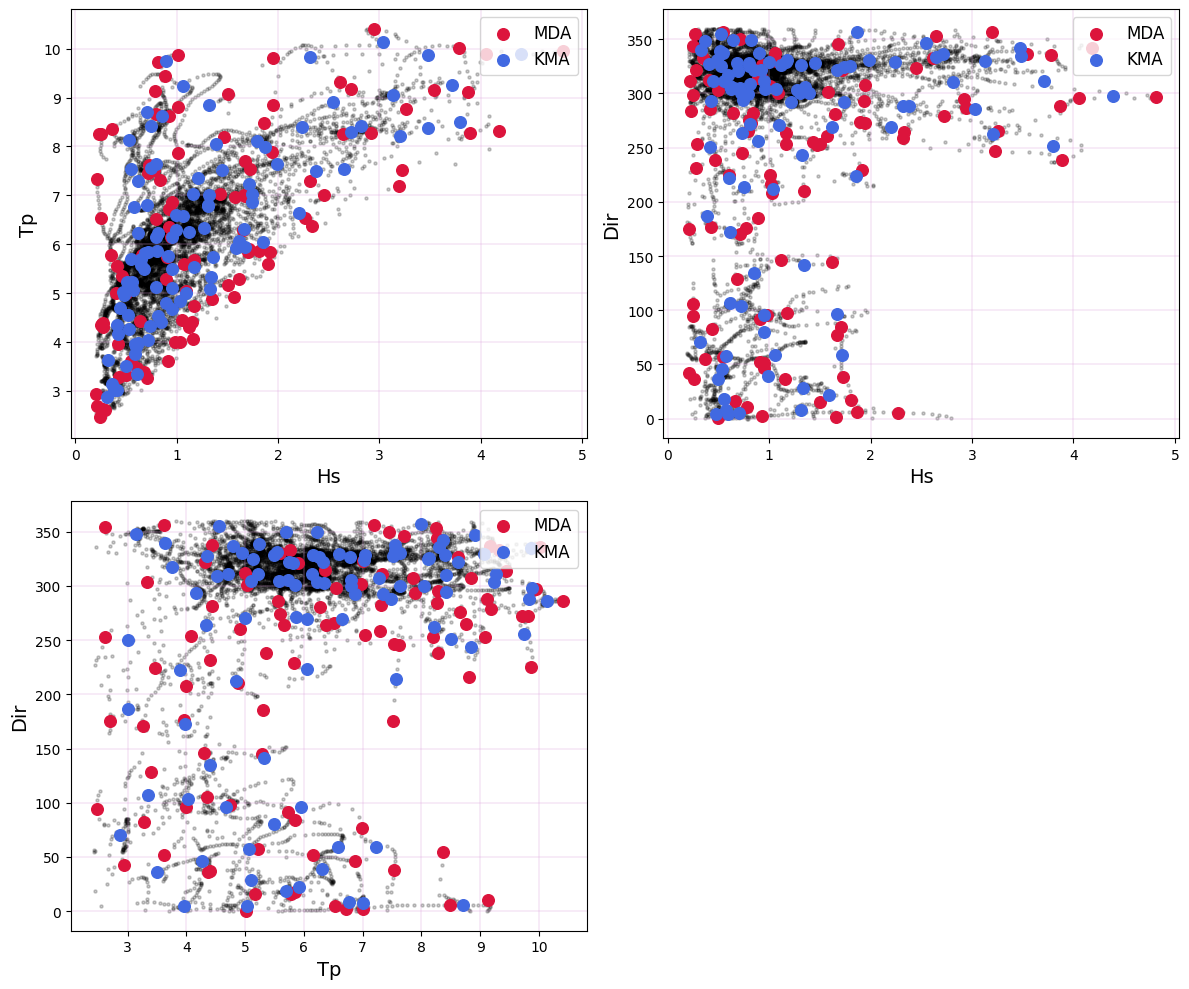

In [7]:
vars = ["Hs", "Tp", "Dir"]  # Lista de variables
sel_mda = mda.centroids[vars]  # Selección de puntos
plot_variable_combinations(
    mda.data, vars, [mda.centroids, kma.centroids], labels=["MDA", "KMA"]
)

### Predict the cluster for a given value using MDA and KMeans

In [8]:
# Generate a sample data to predict:

data_pred = pd.DataFrame({"Hs": [4, 2, 6], "Tp": [12, 10, 15], "Dir": [90, 350, 280]})
data_pred

,Hs,Tp,Dir
0,4,12,90
1,2,10,350
2,6,15,280


### Using MDA

In [9]:
print("\nInput data to predict:")
print(data_pred)

print("\nPredicted Cluster:")
print(mda.centroids.iloc[mda.predict(data_pred)[0]])


Input data to predict:
   Hs  Tp  Dir
0   4  12   90
1   2  10  350
2   6  15  280

Predicted Cluster:
          Hs         Tp     Dir_u     Dir_v     Dir
31  3.781250  10.023438 -0.414693  0.909961  335.50
7   2.613281   9.312500 -0.457874  0.889017  332.75
0   4.812500   9.945312 -0.892979  0.450098  296.75


### Using KMeans

In [10]:
print("\nInput data to predict:")
print(data_pred)

print("\nPredicted Cluster:")
print(kma.centroids.iloc[kma.predict(data_pred)[0].kma_bmus.values])


Input data to predict:
   Hs  Tp  Dir
0   4  12   90
1   2  10  350
2   6  15  280

Predicted Cluster:


ValueError: Buffer dtype mismatch, expected 'const double' but got 'float'